In [ ]:
# Import libraries
import sys
from pathlib import Path

# Add src to path for imports
sys.path.insert(0, '..')

from src.notebook_utils import load_eb_catalog
from src.config import get_config
from data.load_data import get_data_info
import polars as pl
import numpy as np

# Load the eclipsing binary catalog (Parquet format for fast loading)
data = load_eb_catalog(format='polars')

# Display basic information
info = get_data_info(data)
print(f"Dataset contains {info['n_rows']:,} eclipsing binaries")
print(f"Number of columns: {info['n_columns']}")
print(f"\nFirst few column names:")
for i, col in enumerate(info['columns'][:10]):
    print(f"  {i+1}. {col}")
if len(info['columns']) > 10:
    print(f"  ... and {len(info['columns'])-10} more columns")


**This cell will:**
- Initialize the caching system for fast repeated computations
- Show current cache status
- Enable instant loading of expensive calculations after kernel restarts


In [2]:
# Initialize caching system
from visualization.plots import get_cache_info, clear_cache

# Show current cache status
cache_info = get_cache_info()
print("🗂️ CACHE STATUS")
print("="*40)

if cache_info['total_items'] > 0:
    print(f"✅ Found {cache_info['total_items']} cached items ({cache_info['total_size_mb']:.1f} MB)")
    if cache_info['operations']:
        for operation, details in cache_info['operations'].items():
            print(f"   • {operation}: {details['count']} items ({details['size_mb']:.1f} MB)")
    print("🚀 Expensive computations will load instantly!")
else:
    print("📦 No cached items found - computations will be cached as we go")

print(f"\n💡 Cache location: data/cache/")
print("   Survives kernel restarts and session changes!")


🗂️ CACHE STATUS
✅ Found 1 cached items (1.9 MB)
   • sky_plot: 1 items (1.9 MB)
🚀 Expensive computations will load instantly!

💡 Cache location: data/cache/
   Survives kernel restarts and session changes!


**This cell will:**
- Print comprehensive information about the loaded table
- Show column names and data types
- Display a sample of the data to understand the structure

In [3]:
# Print comprehensive table information
print("="*60)
print("ECLIPSING BINARY CATALOG - TABLE INFORMATION")
print("="*60)

info = get_data_info(eb_data)
print(f"\n📊 Dataset Overview:")
print(f"  • Number of objects: {info['n_rows']:,}")
print(f"  • Number of columns: {info['n_columns']}")

print(f"\n📋 Column Information:")
for i, (col, dtype) in enumerate(zip(info['columns'], info['dtypes']), 1):
    print(f"  {i:2d}. {col:<25} ({dtype})")

print(f"\n🔍 Data Sample (first 5 rows):")
print(eb_data.head(5))

print(f"\n📏 Data Shape and Memory:")
print(f"  • Shape: {eb_data.shape}")
print(f"  • Memory usage: ~{eb_data.estimated_size('mb'):.1f} MB")


ECLIPSING BINARY CATALOG - TABLE INFORMATION

📊 Dataset Overview:
  • Number of objects: 1,230,649
  • Number of columns: 14

📋 Column Information:
   1. source_id                 (Int64)
   2. clean_panstarrs1_oid      (Int64)
   3. original_ext_source_id    (Int64)
   4. l                         (Float64)
   5. b                         (Float64)
   6. pmra                      (Float64)
   7. pmdec                     (Float64)
   8. pseudocolour              (Float32)
   9. phot_g_mean_mag           (Float32)
  10. phot_bp_mean_mag          (Float32)
  11. phot_rp_mean_mag          (Float32)
  12. phot_bp_rp_excess_factor  (Float32)
  13. bp_rp                     (Float32)
  14. teff_gspphot              (Float32)

🔍 Data Sample (first 5 rows):
shape: (5, 14)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬──────────┬───────────┐
│ source_id ┆ clean_pan ┆ original_ ┆ l         ┆ … ┆ phot_rp_m ┆ phot_bp_r ┆ bp_rp    ┆ teff_gspp │
│ ---       ┆ starrs1_

**This cell will:**
- Import visualization functions from our custom module
- Plot histograms of effective temperature (teff) values
- Plot histograms of Gaia G photometry (phot_g) values
- Display statistics for each distribution


🔄 Computing histogram data...
💾 Cached result for histograms


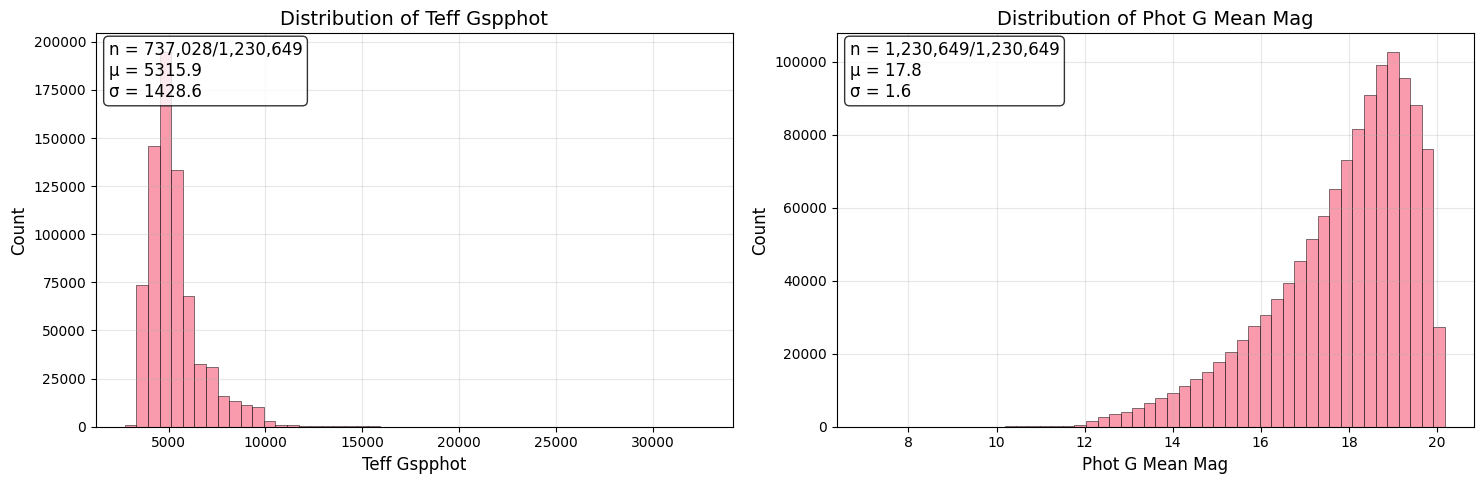


Available columns containing 'teff': ['teff_gspphot']
Available columns containing 'phot_g': ['phot_g_mean_mag']
Plotted columns: ['teff_gspphot', 'phot_g_mean_mag']


In [4]:
# Import visualization functions with caching
from visualization.plots import plot_histograms
import matplotlib.pyplot as plt

# Find temperature and photometry columns
temp_cols = [col for col in eb_data.columns if 'teff' in col.lower()]
phot_g_cols = [col for col in eb_data.columns if 'phot_g' in col.lower() or col.lower() == 'phot_g_mean_mag']

# Select columns to plot
columns_to_plot = []
if temp_cols:
    columns_to_plot.append(temp_cols[0])  # Use first teff column
if phot_g_cols:
    columns_to_plot.append(phot_g_cols[0])  # Use first phot_g column

if columns_to_plot:
    # Create cached histograms for temperature and photometry
    fig = plot_histograms(eb_data, columns_to_plot, bins=50, use_cache=True)
    plt.show()
else:
    print("⚠️ No temperature or photometry columns found!")

# Print column names to verify what we're plotting
print(f"\nAvailable columns containing 'teff': {temp_cols}")
print(f"Available columns containing 'phot_g': {phot_g_cols}")
print(f"Plotted columns: {columns_to_plot}")


**This cell will:**
- Import astronomical visualization functions for sky sphere plotting
- Create all-sky distribution maps in both equatorial and galactic coordinates
- Use Mollweide projection to properly represent the celestial sphere
- Show how the eclipsing binaries are distributed across the sky

Creating sky distribution maps...


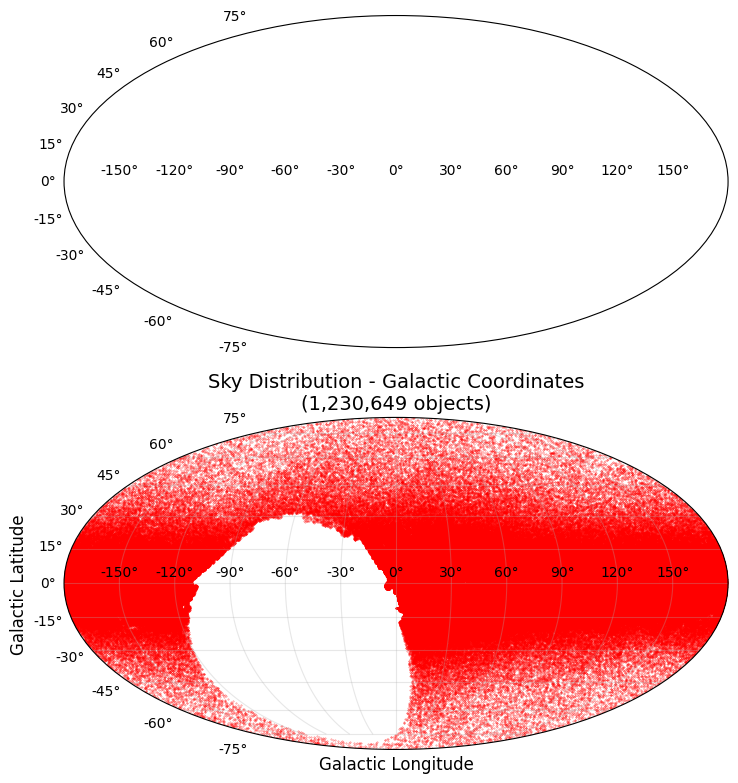


Creating cached temperature-colored sky map...
📦 Loaded cached result for sky_plot


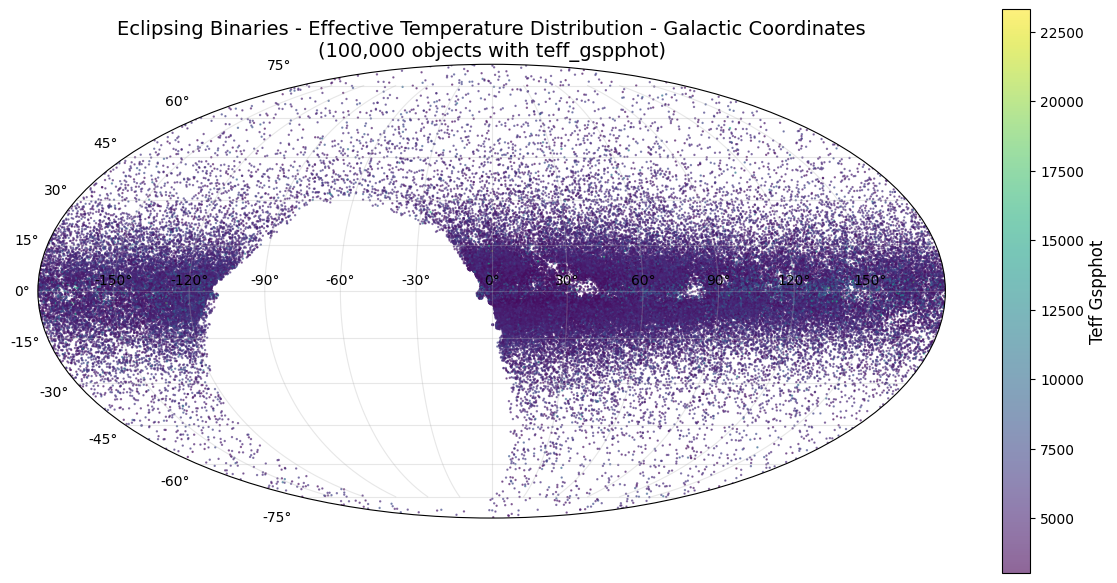


Coordinate columns in dataset:
  • clean_panstarrs1_oid
  • original_ext_source_id
  • l
  • b
  • pmra
  • pmdec
  • pseudocolour
  • phot_bp_mean_mag
  • phot_bp_rp_excess_factor
  • bp_rp

Temperature columns in dataset:
  • teff_gspphot


In [5]:
# Import astronomical sky visualization functions with caching
from visualization.plots import plot_sky_distribution, plot_mollweide_sky_map_cached

# Create all-sky distribution plots in both coordinate systems
print("Creating sky distribution maps...")
fig1 = plot_sky_distribution(eb_data)
plt.show()

# Create a cached Mollweide projection colored by effective temperature
print("\nCreating cached temperature-colored sky map...")
fig2 = plot_mollweide_sky_map_cached(
    eb_data, 
    coord_system='galactic',
    value_col='teff_gspphot',  # Color by effective temperature
    title="Eclipsing Binaries - Effective Temperature Distribution",
    sample_size=100000,  # Subsample for faster plotting
    use_cache=True
)
plt.show()

# Print coordinate column info
print(f"\nCoordinate columns in dataset:")
coord_cols = [col for col in eb_data.columns if any(coord in col.lower() for coord in ['ra', 'dec', 'l', 'b', 'lon', 'lat'])]
for col in coord_cols:
    print(f"  • {col}")
    
print(f"\nTemperature columns in dataset:")
temp_cols = [col for col in eb_data.columns if 'teff' in col.lower()]
for col in temp_cols:
    print(f"  • {col}")


**This cell will:**
- Calculate the proper motion vector magnitude from pmra and pmdec components
- Add the calculated proper motion magnitude as a new column to eb_data
- Plot histogram of proper motion distribution using the caching system
- Show statistics of proper motion values for eclipsing binaries


Found proper motion columns:
  • RA component: ['pmra']
  • Dec component: ['pmdec']

Calculating proper motion magnitude from pmra and pmdec...
✅ Added 'pm_total' column to eb_data

Proper Motion Statistics:
  • Total objects: 1,229,863
  • Valid PM values: 1,229,863
  • Mean: 5.229 mas/yr
  • Median: 4.664 mas/yr
  • Std Dev: 4.206 mas/yr
  • Range: 0.001 - 394.1 mas/yr

Creating proper motion histogram...
🔄 Computing histogram data...
💾 Cached result for histograms


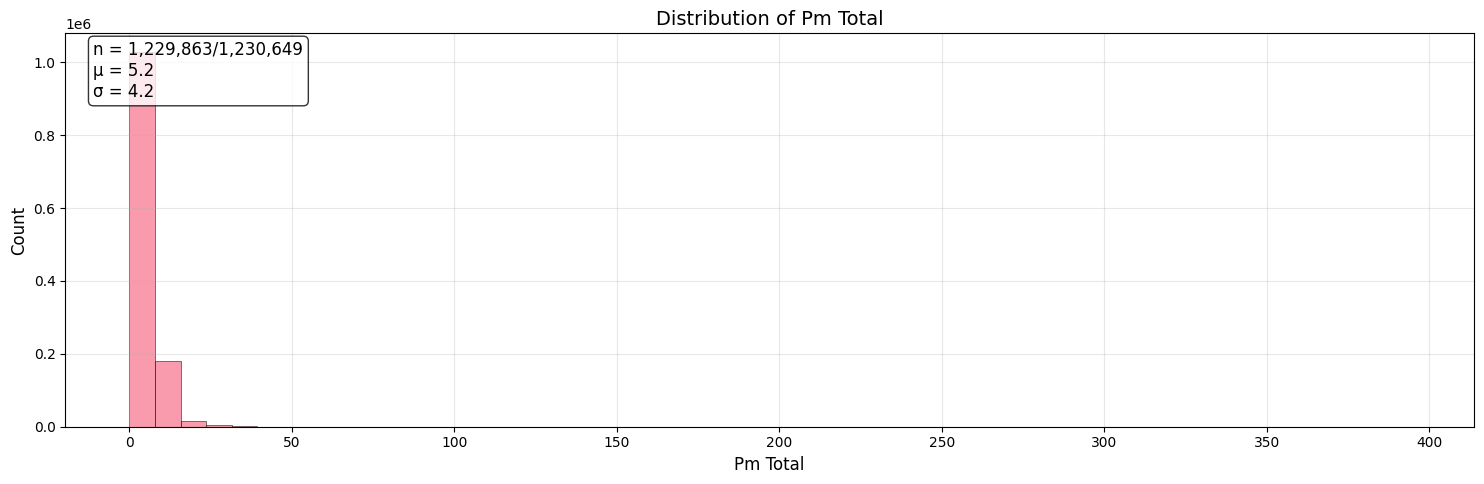


📊 Current eb_data shape: (1230649, 15)
Latest columns: ['phot_rp_mean_mag', 'phot_bp_rp_excess_factor', 'bp_rp', 'teff_gspphot', 'pm_total']


In [6]:
# Calculate proper motion vector magnitude
import numpy as np

# Check if proper motion columns exist
pmra_cols = [col for col in eb_data.columns if 'pmra' in col.lower()]
pmdec_cols = [col for col in eb_data.columns if 'pmdec' in col.lower()]

print("Found proper motion columns:")
print(f"  • RA component: {pmra_cols}")
print(f"  • Dec component: {pmdec_cols}")

if pmra_cols and pmdec_cols:
    pmra_col = pmra_cols[0]  # Use first pmra column
    pmdec_col = pmdec_cols[0]  # Use first pmdec column
    
    # Calculate proper motion magnitude: sqrt(pmra² + pmdec²)
    print(f"\nCalculating proper motion magnitude from {pmra_col} and {pmdec_col}...")
    
    eb_data = eb_data.with_columns(
        (
            (pl.col(pmra_col)**2 + pl.col(pmdec_col)**2)**0.5
        ).alias("pm_total")
    )
    
    print(f"✅ Added 'pm_total' column to eb_data")
    
    # Show basic statistics
    pm_stats = eb_data.select([
        pl.col("pm_total").count().alias("count"),
        pl.col("pm_total").drop_nulls().count().alias("valid_count"),
        pl.col("pm_total").mean().alias("mean"),
        pl.col("pm_total").std().alias("std"),
        pl.col("pm_total").min().alias("min"),
        pl.col("pm_total").max().alias("max"),
        pl.col("pm_total").quantile(0.5).alias("median")
    ])
    
    print(f"\nProper Motion Statistics:")
    print(f"  • Total objects: {pm_stats['count'][0]:,}")
    print(f"  • Valid PM values: {pm_stats['valid_count'][0]:,}")
    print(f"  • Mean: {pm_stats['mean'][0]:.3f} mas/yr")
    print(f"  • Median: {pm_stats['median'][0]:.3f} mas/yr")
    print(f"  • Std Dev: {pm_stats['std'][0]:.3f} mas/yr")
    print(f"  • Range: {pm_stats['min'][0]:.3f} - {pm_stats['max'][0]:.1f} mas/yr")
    
    # Plot histogram using cached function
    print(f"\nCreating proper motion histogram...")
    fig = plot_histograms(eb_data, ['pm_total'], bins=50, use_cache=True,
                         title_prefix="Distribution of")
    plt.show()
    
else:
    print("⚠️ Proper motion columns (pmra, pmdec) not found in the dataset!")
    print("Available columns containing 'pm':")
    pm_cols = [col for col in eb_data.columns if 'pm' in col.lower()]
    for col in pm_cols:
        print(f"  • {col}")

print(f"\n📊 Current eb_data shape: {eb_data.shape}")
print(f"Latest columns: {eb_data.columns[-5:]}")  # Show last 5 columns


**This cell will:**
- Count null values in each column (excluding ID columns)
- Analyze cross-correlations between null values in different columns
- Identify objects missing multiple measurements
- Create a comprehensive data completeness analysis
- Show which combinations of missing values are most common


In [9]:

# Display null value summary
for col, stats in sorted_nulls:
    if stats['count'] > 0:  # Only show columns with nulls
        print(f"{col:<25} | {stats['count']:>8,} nulls ({stats['percentage']:>5.1f}%)")

# Count columns by completeness
complete_cols = [col for col, stats in null_counts.items() if stats['count'] == 0]
partial_cols = [col for col, stats in null_counts.items() if 0 < stats['count'] < total_objects]
empty_cols = [col for col, stats in null_counts.items() if stats['count'] == total_objects]

print(f"\n📈 COMPLETENESS SUMMARY")
print("-"*30)
print(f"Complete columns (0% null):     {len(complete_cols):3d}")
print(f"Partial columns (some nulls):   {len(partial_cols):3d}")
print(f"Empty columns (100% null):      {len(empty_cols):3d}")

if empty_cols:
    print(f"\nEmpty columns: {empty_cols}")

# Analyze null value combinations for key columns
print(f"\n🔗 NULL VALUE CROSS-ANALYSIS")
print("-"*60)

# Select key columns for cross-analysis (those with some but not all nulls)
key_cols = [col for col, stats in sorted_nulls[:10] if 0 < stats['count'] < total_objects]
if len(key_cols) > 8:  # Limit to avoid overwhelming output
    key_cols = key_cols[:8]

print(f"Analyzing cross-correlations for top {len(key_cols)} columns with missing data:")
for col in key_cols:
    print(f"  • {col}")

if key_cols:
    # Create null indicator dataframe for cross-analysis
    null_indicators = eb_data.select([
        pl.col(col).is_null().alias(f"{col}_null") for col in key_cols
    ])
    
    # Convert to pandas for easier cross-tabulation
    null_df = null_indicators.to_pandas()
    
    # Count objects missing multiple values
    null_df['missing_count'] = null_df.sum(axis=1)
    
    print(f"\n📋 OBJECTS BY NUMBER OF MISSING VALUES")
    print("-"*40)
    missing_dist = null_df['missing_count'].value_counts().sort_index()
    for missing_count, object_count in missing_dist.items():
        pct = (object_count / total_objects) * 100
        print(f"{missing_count} missing values: {object_count:>8,} objects ({pct:>5.1f}%)")
    
    # Find most common combinations of missing values
    print(f"\n🔍 MOST COMMON MISSING VALUE COMBINATIONS")
    print("-"*50)
    
    # Group by missing value patterns (use the _null column names)
    null_col_names = [f"{col}_null" for col in key_cols]
    pattern_counts = null_df[null_col_names].apply(
        lambda row: tuple(key_cols[i] for i, is_null in enumerate(row) if is_null), axis=1
    ).value_counts()
    
    # Show top 10 patterns (excluding complete data)
    top_patterns = pattern_counts[pattern_counts.index != ()].head(10)
    
    for i, (pattern, count) in enumerate(top_patterns.items(), 1):
        pct = (count / total_objects) * 100
        if len(pattern) == 1:
            print(f"{i:2d}. Only {pattern[0]} missing: {count:>6,} objects ({pct:4.1f}%)")
        elif len(pattern) <= 3:
            pattern_str = " + ".join(pattern)
            print(f"{i:2d}. {pattern_str} missing: {count:>6,} objects ({pct:4.1f}%)")
        else:
            print(f"{i:2d}. {len(pattern)} columns missing: {count:>6,} objects ({pct:4.1f}%)")

# Summary statistics
objects_with_complete_data = len(eb_data.filter(
    pl.all_horizontal([pl.col(col).is_not_null() for col in key_cols])
))
objects_missing_any = total_objects - objects_with_complete_data

print(f"\n📊 OVERALL DATA QUALITY")
print("-"*30)
print(f"Objects with complete data (top {len(key_cols)} cols): {objects_with_complete_data:>8,} ({(objects_with_complete_data/total_objects)*100:4.1f}%)")
print(f"Objects missing any value:                {objects_missing_any:>8,} ({(objects_missing_any/total_objects)*100:4.1f}%)")

print(f"\n💡 This analysis helps identify which measurements are systematically missing")
print(f"   and whether missing values tend to occur together in specific patterns.")


🔍 DATA COMPLETENESS ANALYSIS
Total objects in dataset: 1,230,649

Excluding ID columns: ['source_id', 'clean_panstarrs1_oid', 'original_ext_source_id']
Analyzing 12 non-ID columns

📊 NULL VALUES PER COLUMN
------------------------------------------------------------
pseudocolour              |  771,107 nulls ( 62.7%)
teff_gspphot              |  493,621 nulls ( 40.1%)
phot_bp_rp_excess_factor  |   23,283 nulls (  1.9%)
bp_rp                     |   23,283 nulls (  1.9%)
phot_bp_mean_mag          |   23,081 nulls (  1.9%)
phot_rp_mean_mag          |   22,344 nulls (  1.8%)
pmra                      |      786 nulls (  0.1%)
pmdec                     |      786 nulls (  0.1%)
pm_total                  |      786 nulls (  0.1%)

📈 COMPLETENESS SUMMARY
------------------------------
Complete columns (0% null):       3
Partial columns (some nulls):     9
Empty columns (100% null):        0

🔗 NULL VALUE CROSS-ANALYSIS
------------------------------------------------------------
Analyzing cr

**This cell will:**
- Save the updated eclipsing binary catalog with the new `pm_total` column to Parquet format
- Create a new processed file with all computed columns included
- Show file size comparison and compression statistics
- Update the cache to reflect the new data structure


In [ ]:
# Save updated table with pm_total column
from pathlib import Path
import time

from src.config import get_config

print("💾 SAVING UPDATED CATALOG")
print("="*40)

# Get configuration
config = get_config()
output_file = config.get_path('processed') / 'eb_catalog_with_pm.parquet'
original_file = config.get_path('processed') / 'eb_catalog.parquet'

print(f"Current data shape: {eb_data.shape}")
print(f"Columns: {eb_data.width}")
print(f"Rows: {eb_data.height:,}")

# Check if pm_total column exists
if 'pm_total' in eb_data.columns:
    print(f"✅ pm_total column found in data")
    
    # Get column info
    pm_stats = eb_data.select([
        pl.col("pm_total").count().alias("total"),
        pl.col("pm_total").drop_nulls().count().alias("valid"),
    ])
    print(f"   • Total values: {pm_stats['total'][0]:,}")
    print(f"   • Valid values: {pm_stats['valid'][0]:,}")
    print(f"   • Completeness: {(pm_stats['valid'][0]/pm_stats['total'][0])*100:.1f}%")
else:
    print("⚠️ pm_total column not found! Make sure to run the proper motion calculation cell first.")

# Save the updated data
print(f"\nSaving to: {output_file}")
start_time = time.time()

try:
    eb_data.write_parquet(output_file)
    save_time = time.time() - start_time
    print(f"✅ Successfully saved in {save_time:.2f} seconds")
    
    # File size comparison
    if output_file.exists():
        new_size = output_file.stat().st_size / (1024**2)  # MB
        print(f"   • File size: {new_size:.1f} MB")
        
        if original_file.exists():
            original_size = original_file.stat().st_size / (1024**2)  # MB
            size_diff = new_size - original_size
            print(f"   • Original file: {original_size:.1f} MB")
            print(f"   • Size increase: +{size_diff:.1f} MB")
        
        # Memory usage estimate
        memory_usage = eb_data.estimated_size('mb')
        compression_ratio = memory_usage / new_size if new_size > 0 else 0
        print(f"   • In-memory size: ~{memory_usage:.1f} MB")
        print(f"   • Compression ratio: {compression_ratio:.1f}x")
    
    # Clear cache since data structure changed
    print(f"\n🗑️ Clearing cache due to data structure change...")
    clear_cache()
    
    print(f"\n💡 Updated catalog saved successfully!")
    print(f"   Use this file for future analysis to include proper motion data.")
    print(f"   Original file preserved at: {original_file}")
    
except Exception as e:
    print(f"❌ Error saving file: {e}")

# Verify the saved file
if output_file.exists():
    print(f"\n✅ VERIFICATION")
    print("-"*20)
    
    # Try loading a sample to verify integrity
    try:
        test_load = pl.read_parquet(output_file)
        print(f"✅ File loads successfully")
        print(f"   • Shape: {test_load.shape}")
        print(f"   • Has pm_total: {'pm_total' in test_load.columns}")
        
        if 'pm_total' in test_load.columns:
            valid_pm = test_load['pm_total'].drop_nulls().len()
            print(f"   • Valid pm_total values: {valid_pm:,}")
            
    except Exception as e:
        print(f"⚠️ Error verifying saved file: {e}")

print(f"\n🎯 Next steps:")
print(f"   • Update data loading to use the new file")
print(f"   • Run analysis on proper motion distributions")
print(f"   • Cache will rebuild automatically for new data structure")
